D:\Projects\tumor-immune-scrna-atlas
AnnData object with n_obs × n_vars = 46435 × 39241
    obs: 'barcode', 'sample_id', 'patient_id', 'gsm', 'egfr_status', 'egfr_mutation', 'age', 'sex', 'smoking', 'stage', 'pdl1_tps', 'tmb', 'concomitant_mutations', 'viability'
sample_id
CYD      5337
CYZ      5272
GBG      5347
LJQ      4463
LYB.1    5321
LYB.2    5416
TGS      5141
XMS      5173
ZYQ      4965
Name: count, dtype: int64
egfr_status
mutant      25437
wildtype    20998
Name: count, dtype: int64


C:\Users\akksh\AppData\Local\Temp\ipykernel_102348\3013754238.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('egfr_status').size().plot.bar(


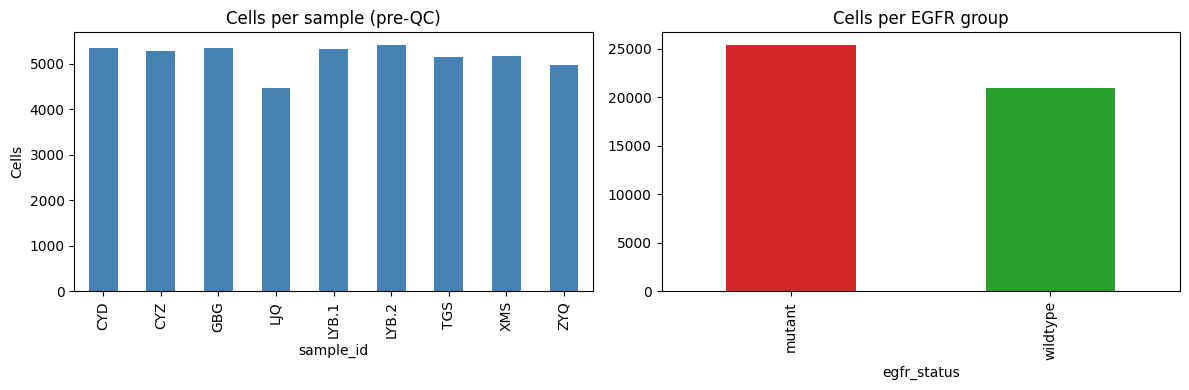

In [4]:
import os
os.chdir('D:/Projects/tumor-immune-scrna-atlas')
print(os.getcwd())
# Load just LJQ to confirm format
import sys
#!{sys.executable} -m pip install scanpy
import scanpy as sc
import matplotlib.pyplot as plt
 
adata = sc.read_h5ad('data/raw/01_concatenated.h5ad')
print(adata)
 
# Cells per sample
counts = adata.obs['sample_id'].value_counts().sort_index()
print(counts)
 
# Cells per EGFR group
print(adata.obs['egfr_status'].value_counts())
 
# Visual check: bar plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title('Cells per sample (pre-QC)')
axes[0].set_ylabel('Cells')
 
adata.obs.groupby('egfr_status').size().plot.bar(
    ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_title('Cells per EGFR group')
plt.tight_layout()
plt.savefig('results/figures/00_load_summary.png', dpi=300)